In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

## Data Generation: Sine Curves

Generate **10,000 sine curves** of the form:

$$
x(t) = A \cdot \sin(\omega t + \phi)
$$

where the parameters are drawn from uniform distributions:

- Amplitude: $ A \sim \mathcal{U}[0.5, 1.5] $
- Frequency: $ \omega \sim \mathcal{U}[0.5, 2] $
- Phase: $ \phi \sim \mathcal{U}[0, 2\pi] $

Sample each curve at $N = 100$ equally spaced points over $t \in [0, 4\pi]$.
Your clean_curve array should have shape (10000, 100).

In [5]:
# generate dataset
#define parameters
A = np.random.rand(10000) + 0.5
omega = 1.5 * np.random.rand(10000) + 0.5
phi = 2 * np.pi * np.random.rand(10000)
t = np.linspace(0, 4 * np.pi, 100)
clean_curve = np.zeros([10000, 100])
for i in range(100):
    x = lambda t: A * np.sin(omega * t + phi)
    clean_curve[:,i] = x(t[i])
clean_curve

array([[ 0.49263534,  0.57054861,  0.64552988, ...,  1.07351959,
         1.11076341,  1.1422991 ],
       [ 0.02768004, -0.10015605, -0.22449872, ...,  0.46607751,
         0.36449019,  0.25018957],
       [-0.69877308, -0.74159738, -0.77690682, ...,  0.813329  ,
         0.82917902,  0.83662668],
       ...,
       [ 0.65994586,  0.72722834,  0.7527448 , ..., -0.51990532,
        -0.37540248, -0.20933961],
       [-0.0528474 ,  0.13744265,  0.32522572, ...,  0.68389393,
         0.84374588,  0.98820776],
       [-0.67611064, -0.72774649, -0.77419302, ..., -0.37891835,
        -0.30578418, -0.23046955]], shape=(10000, 100))

## Add Gaussian Noise

$$
x_{\text{noisy}}(t) = x(t) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.2
$$
Your noisy_curve array should have shape (10000, 100).

In [6]:
# generate noisy data
epsilon = np.random.normal(0, 0.2, [10000, 100])
noisy_curve = clean_curve + epsilon
noisy_curve

array([[ 0.54517156,  0.94933877,  0.79204716, ...,  0.8816304 ,
         0.91962991,  1.36976103],
       [ 0.08146655, -0.31795648, -0.2370594 , ...,  0.43096886,
         0.37806114,  0.03694846],
       [-1.11223571, -0.95584157, -0.70080445, ...,  0.95508194,
         0.89100552,  0.67094184],
       ...,
       [ 0.89302603,  0.50464692,  0.54001823, ..., -0.29523793,
        -0.38827229, -0.29207615],
       [-0.11908954,  0.5194318 ,  0.49044275, ...,  0.54552907,
         0.96514461,  1.23379342],
       [-0.92155449, -0.54191482, -0.56085898, ..., -0.80694965,
        -0.38368579, -0.10333522]], shape=(10000, 100))

Plot examples showing the clean and noisy curve.

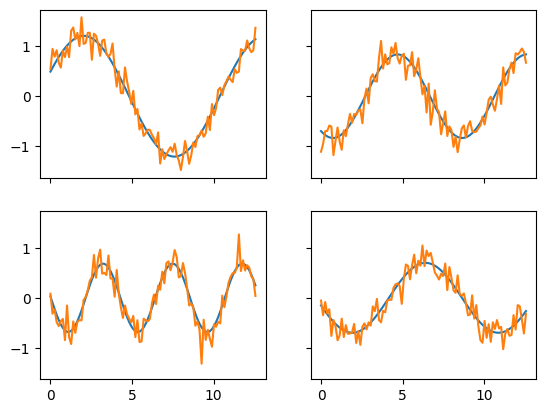

In [11]:
# plot clean vs noisy examples
fig, axes = plt.subplots(2, 2, sharex = True, sharey = True)
ax = axes[0,0]
ax.plot(t, clean_curve[0,:])
ax.plot(t, noisy_curve[0,:])

ax = axes[1,0]
ax.plot(t, clean_curve[1,:])
ax.plot(t, noisy_curve[1,:])

ax = axes[0,1]
ax.plot(t, clean_curve[2,:])
ax.plot(t, noisy_curve[2,:])

ax = axes[1,1]
ax.plot(t, clean_curve[3,:])
ax.plot(t, noisy_curve[3,:])

## Dataset Split

Split into **90% training / 10% validation**.
- **Input**  (noisy_curve) : X_train -> shape (9000, 100), X_val -> shape (1000, 100)
- **Target** (clean_curve): Y_train -> shape (9000, 100), Y_val -> shape (1000, 100)

In [ ]:
# dataset split

## Autoencoder Model

**Fully connected (dense) autoencoder**
- **Encoder** compresses the input into a low-dimensional **latent space**
- **Decoder** reconstructs the signal from the latent representation

The network is trained to minimise **mean squared error (MSE)** between the reconstructed and clean signal.

In [ ]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

## Training with .fit()

.fit() trains the model. The key arguments are:

| Argument | What it means |
|---|---|
| X_train, Y_train | The data the model learns from |
| epochs | How many times the model sees the full training data |
| batch_size | How many samples to process before updating the weights |
| validation_data=(X_val, Y_val) | Data the model never trains on. It is used to check performance after each epoch |
| verbose=1 | Shows a progress bar while training; set to 0 to hide it |

After training, history stores the training loss and validation loss at every epoch:

If validation loss starts increasing while training loss keeps decreasing -> the model is **overfitting** (memorising the training data instead of generalising).

In [ ]:
history = autoencoder.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, Y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Plot the training and validation loss curves.

In [ ]:
# plot loss curves

## Making Predictions with .predict()

model.predict(X) passes the input array through the trained network and returns reconstructed outputs.

In [ ]:
examples = [0, 1, 2, 3]

reconstructed_Y = autoencoder.predict(X_val[examples]) # Returns shape (4, 100)

Plot the clean signal, noisy input, and reconstructed signal.

In [ ]:
# Plot clean / noisy / reconstructed for each example